# 일주일 데이터로 Lifetime을 예측하라구요? — lifetime 추정 실습

유저 한 명이 가입 후 이탈 전까지 평균 며칠을 활동하는가 — 이 **lifetime**은
`D1 + D2 + ... + D365` retention의 합, 즉 *retention 곡선 아래의 면적*과 같습니다.
문제는 1년을 기다리지 않고 **초기 7일치 데이터**만으로 그 면적을 메워야 한다는 점입니다.

이 노트북은 같은 신규 코호트의 7일 관측치에 대해 세 가지 추정법을 차례로 적용하고,
마지막에 세 답을 한 표에서 비교합니다.

| 방법 | D8~D365를 어디서 가져오나 | 모델 가정 |
| :-- | :-- | :-- |
| **1) 이탈률 휴리스틱** | 등비급수로 외삽 | 강함 (이탈률 안정화) |
| **2) 리텐션 카탈로그 매칭** | 사전 계산된 카탈로그에서 매칭 | 중간 (sBG 카탈로그) |
| **3) 장기 코호트 직접 측정** | 1년 전 코호트 실측 | 약함 (7일 면적 비례) |


## 0. 준비

아래 셀은 의존성을 설치합니다. 데이터가 없다면 먼저 터미널에서
`python generate_data.py` 를 실행해 예시 데이터(`data/cohort_retention.csv`)를 만들어 주세요.

의존성은 이미 설치돼 있으면 빠르게 넘어갑니다.

> **[내 데이터 적용]** `DAYS` 는 lifetime을 며칠까지 합산할지입니다. 365일 뒤에도 retention이
> 높게 남는 서비스라면 730·1095로 늘립니다.

In [1]:
# 의존성 설치 
%pip install -q -r requirements.txt

# 실습용 데이터베이스 세팅 
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# DuckDB 인메모리 연결 하나를 만들어 노트북 전체에서 재사용합니다.
con = duckdb.connect()

DAYS = 365   # lifetime은 1년치 retention 합으로 근사


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## 신규 코호트 데이터 준비

7일 전 가입한 신규 코호트의 일별 retention을 미리 만들어 `cohort_retention.csv`로 준비해
두었습니다. D0~D7까지 8일치만 관측돼 있고, 이 데이터가 세 방법 모두의 입력값이 됩니다.
실제 운영 환경이라면 raw 이벤트 로그에서 매일 집계해 만드는 코호트 리텐션 마트의
한 코호트 분량이라고 보시면 됩니다.

등록한 테이블은 이후 모든 SQL이 `cohort_retention` 이름으로 참조합니다.

> **[내 데이터 적용]** 내 서비스의 코호트 리텐션 CSV로 바꿉니다 (컬럼: `day`, `retention` —
> D0=1.0에서 시작).

In [2]:
# CSV를 읽어 DuckDB 테이블로 등록 

con.execute(""" 
CREATE OR REPLACE TABLE cohort_retention AS 
SELECT * FROM read_csv_auto('data/cohort_retention.csv') 
""") 

con.execute("SELECT * FROM cohort_retention ORDER BY day").df() 

,day,retention
0,0,1.000
1,1,0.341
2,2,0.295
3,3,0.273
4,4,0.260
5,5,0.252
6,6,0.247
7,7,0.244


## 1) 이탈률 휴리스틱

가장 단순한 방법입니다. 신규 코호트의 D1~D7 면적에다, D7 이후의 무한 등비급수 꼬리를 더합니다.

$$ \text{lifetime} \approx (D_1 + D_2 + \cdots + D_7) + \frac{D_7 \cdot r}{1 - r} $$

여기서 $r$은 안정화된 일별 retention 비율로, 후반부 며칠치 비율(D5/D4, D6/D5, D7/D6)을 평균 내서 잡습니다.

> **[내 데이터 적용]** r(안정화 비율) 추정 구간은 아래 SQL의 `WHERE day BETWEEN 5 AND 7` 입니다.
> 관측 일수가 더 길면 D8~D14처럼 더 안정된 구간으로 넓히면 r 추정이 견고해집니다.

In [3]:
heuristic_query = """
WITH observed_area AS (
  SELECT SUM(retention) AS area_d1_d7
  FROM cohort_retention
  WHERE day BETWEEN 1 AND 7
),
daily_ratios AS (
  SELECT day, retention,
         retention / LAG(retention) OVER (ORDER BY day) AS ratio
  FROM cohort_retention
),
r_estimate AS (
  SELECT AVG(ratio) AS r
  FROM daily_ratios
  WHERE day BETWEEN 5 AND 7        -- D5/D4, D6/D5, D7/D6
),
d7_value AS (
  SELECT retention AS d7 FROM cohort_retention WHERE day = 7
)
SELECT
  ROUND(o.area_d1_d7, 3)                          AS observed_d1_d7_area,
  ROUND(d.d7, 3)                                  AS d7,
  ROUND(r.r, 4)                                   AS estimated_r,
  ROUND(d.d7 * r.r / (1 - r.r), 2)                AS extrapolated_tail_area,
  ROUND(o.area_d1_d7 + d.d7 * r.r / (1 - r.r), 2) AS lifetime_estimate
FROM observed_area o, r_estimate r, d7_value d
"""
heuristic = con.execute(heuristic_query).df()
heuristic

,observed_d1_d7_area,d7,estimated_r,extrapolated_tail_area,lifetime_estimate
0,1.912,0.244,0.9791,11.42,13.33


직접 관측한 7일치 면적은 1.91일에 불과하지만, r ≈ 0.9791을 바탕으로 추정한 꼬리
면적(11.42일)을 더하면 총 lifetime은 약 **13.33일**로 산출됩니다.

핵심은 — *r이 1에 가까울수록 꼬리가 폭발적으로 길어진다*는 점입니다. r이 0.98이면 꼬리가
D7의 49배지만, 0.99로 올라가면 99배가 됩니다. 결정적으로 실제 retention 곡선은 시간이
흐를수록 잔존비율 r이 점점 1에 가까워지는 **'두꺼운 꼬리(Heavy Tail)'** 특성을 보입니다.
초기 7일 데이터만으로 고정한 r은 후반부의 두꺼운 꼬리를 포착하지 못하므로, 이탈률 휴리스틱은
lifetime을 **구조적으로 과소추정(Underestimate)**합니다. 이게 휴리스틱의 가장 큰 약점입니다.

## 2) 리텐션 카탈로그 매칭

두 번째 방법은 미리 그려 둔 곡선 카탈로그에서 신규 코호트와 가장 닮은 곡선을 찾아,
그 곡선에 적힌 lifetime을 가져오는 방식입니다. 다른 두 방법과 달리 **곡선 카탈로그**를
먼저 만들어야 하므로, 카탈로그 생성 → 매칭 순으로 진행합니다.

### 카탈로그 만들기

곡선은 이탈률의 이형성(Heterogeneity)을 반영하는 **sBG**(shifted Beta-Geometric) 모델로
만듭니다. sBG는 두 파라미터 `(a, c)`로 다양한 모양의 retention 곡선을 그려 내는데, 여기서는
*(a, c)는 곡선 모양을 결정하는 두 손잡이* 정도로만 받아들이면 됩니다. 여기에 가입 다음 날
retention인 **D1 anchor**를 추가로 받습니다 (D1은 서비스마다 천차만별이라 한 값으로 고정하면
카탈로그가 한 서비스에만 쓰이게 됩니다).

| 차원 | 격자 |
| :-- | :-- |
| D1 anchor | 0.15, 0.20, ..., 0.50 (8값) |
| a | 0.05 ~ 1.00을 25등분 |
| c | 1.0 ~ 4.0을 10등분 |

세 차원을 곱하면 8 × 25 × 10 = **2,000장**의 곡선이 만들어집니다.

> **[내 데이터 적용]** 카탈로그 격자 범위입니다. 내 서비스 D1이 0.15~0.50을 벗어나면 anchor
> 범위를 넓히고, 더 촘촘한 매칭을 원하면 격자 수(25, 10)를 키웁니다.

In [4]:
def sbg_curve(a, c, d1, days=DAYS):
    """sBG 모델로 D0 ~ D{days}의 retention 곡선 생성."""
    D = [1.0, d1]                      # D0=1, D1은 입력 anchor
    for t in range(2, days + 1):
        r_t = (c + t - 2) / (a + c + t - 2)
        D.append(D[-1] * r_t)
    return D


d1_anchors = np.round(np.arange(0.15, 0.55, 0.05), 2)
a_grid     = np.round(np.linspace(0.05, 1.0, 25), 4)
c_grid     = np.round(np.linspace(1.0, 4.0, 10), 4)

rows = []
for d1 in d1_anchors:
    for a in a_grid:
        for c in c_grid:
            D = sbg_curve(a, c, d1)
            row = {'a': a, 'c': c}
            row.update({f'D{t}': D[t] for t in range(DAYS + 1)})
            row['lifetime'] = sum(D[1:])   # D1 ~ D365의 합 = 곡선 면적
            rows.append(row)

catalog = pd.DataFrame(rows)
print(f'카탈로그 생성 완료: {len(catalog):,}장 (8 x 25 x 10)')
print(f'  D1 범위:       {catalog["D1"].min():.2f} ~ {catalog["D1"].max():.2f}')
print(f'  lifetime 범위: {catalog["lifetime"].min():.1f} ~ {catalog["lifetime"].max():.1f}일')

카탈로그 생성 완료: 2,000장 (8 x 25 x 10)
  D1 범위:       0.15 ~ 0.50
  lifetime 범위: 1.0 ~ 151.9일


카탈로그의 한 행이 곧 하나의 retention 곡선입니다. D0~D365 컬럼에 일별 retention이,
마지막 `lifetime` 컬럼에 그 곡선의 면적이 미리 계산돼 있습니다. lifetime 컬럼만 봐도
(a, c)·D1 조합에 따라 1일에서 150일대까지 매우 넓은 범위를 덮는 게 확인됩니다.

In [5]:
# 앞쪽 몇 개 컬럼만 추려서 카탈로그 모양 미리보기
catalog[['a', 'c', 'D0', 'D1', 'D2', 'D3', 'D7', 'D365', 'lifetime']].head()

,a,c,D0,D1,D2,D3,D7,D365,lifetime
0,0.05,1.0000,1.0,0.15,0.142857,0.139373,0.132947,0.108728,41.766677
1,0.05,1.3333,1.0,0.15,0.144578,0.141545,0.135512,0.111097,42.663065
2,0.05,1.6667,1.0,0.15,0.145631,0.142951,0.137283,0.112810,43.308932
3,0.05,2.0000,1.0,0.15,0.146341,0.143942,0.138604,0.114149,43.811660
4,0.05,2.3333,1.0,0.15,0.146853,0.144683,0.139642,0.115247,44.222592


### 카탈로그 둘러보기 — 100장 무작위 샘플

표로는 카탈로그의 다양성이 잘 와닿지 않으니, 곡선을 직접 겹쳐 그려 봅니다. 2,000장을
한꺼번에 그리면 서로 뭉개져 알아보기 어려우므로, **무작위로 100장만 뽑아** lifetime에 따라
색을 입혀 그렸습니다(재현을 위해 `random_state` 고정). 모든 곡선이 D0=1.0에서 출발해 각자의
D1 anchor로 내려앉은 뒤, (a, c)에 따라 서로 다른 두께의 꼬리로 흩어지는 모습이 보입니다 —
색이 밝을수록(노랑) 꼬리가 두꺼워 lifetime이 긴 곡선입니다.

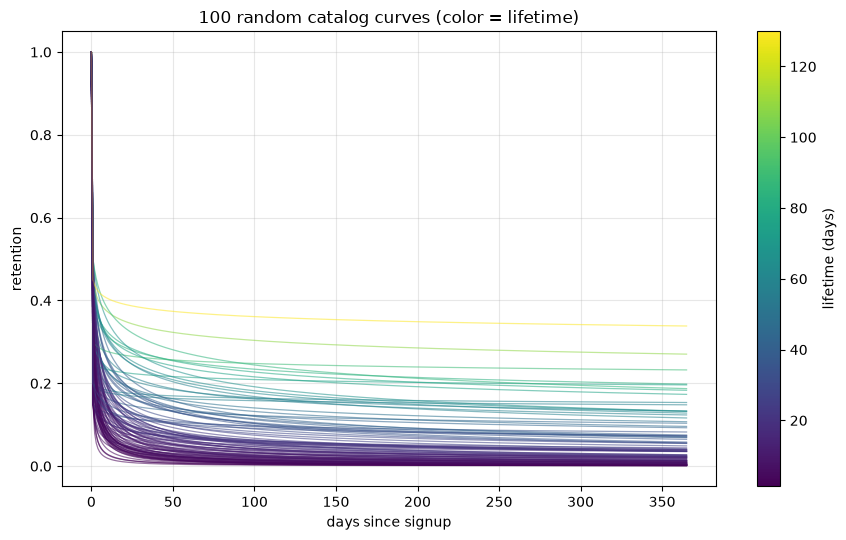

In [6]:
# 2,000장 중 100장만 무작위 추출해 겹쳐 그리기 (lifetime으로 색 구분)
sample = catalog.sample(100, random_state=42)
day_cols = [f'D{t}' for t in range(DAYS + 1)]

fig, ax = plt.subplots(figsize=(9, 5.5))
norm = plt.Normalize(sample['lifetime'].min(), sample['lifetime'].max())
cmap = plt.cm.viridis
for _, row in sample.iterrows():
    ax.plot(range(DAYS + 1), row[day_cols].to_numpy(dtype=float),
            color=cmap(norm(row['lifetime'])), alpha=0.55, linewidth=0.9)
ax.set_title('100 random catalog curves (color = lifetime)')
ax.set_xlabel('days since signup'); ax.set_ylabel('retention')
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
fig.colorbar(sm, ax=ax, label='lifetime (days)')
plt.tight_layout(); plt.show()

방금은 카탈로그 전체를 훑어봤으니, 이번엔 세 차원이 각각 곡선에 어떤 영향을 주는지
축별로 뜯어보겠습니다. 두 패널로 나눠 — 하나는 *D1만 변할 때*, 다른 하나는 *(a, c)만 변할 때*
— 곡선이 어떻게 달라지는지 봅니다.

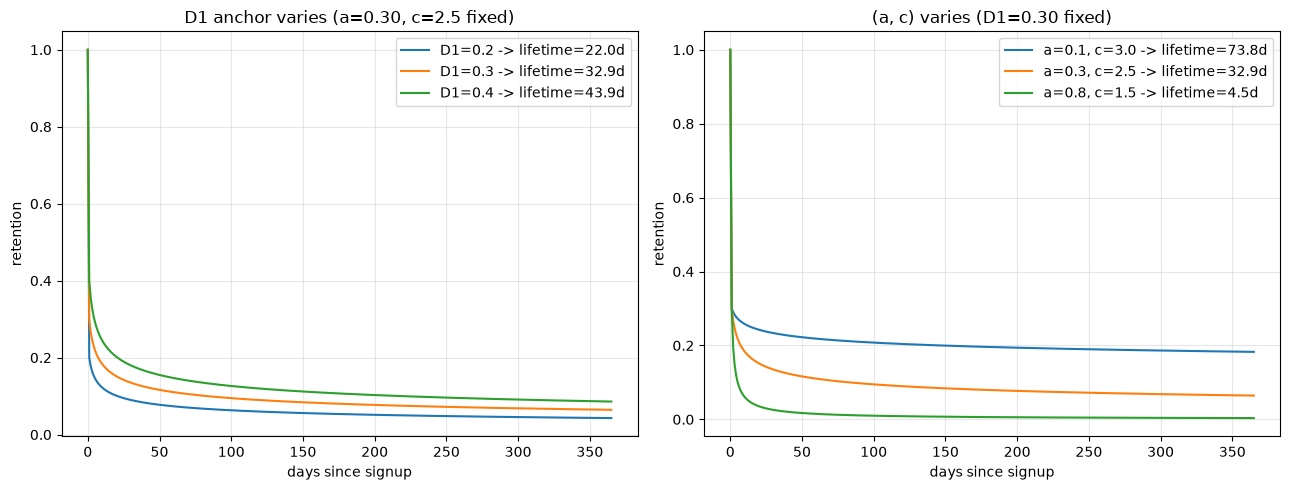

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: (a, c)=(0.30, 2.5) 고정, D1만 변화
for d1 in [0.20, 0.30, 0.40]:
    D = sbg_curve(0.30, 2.5, d1)
    axes[0].plot(range(DAYS + 1), D, label=f'D1={d1} -> lifetime={sum(D[1:]):.1f}d')
axes[0].set_title('D1 anchor varies (a=0.30, c=2.5 fixed)')
axes[0].set_xlabel('days since signup'); axes[0].set_ylabel('retention')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 오른쪽: D1=0.30 고정, (a, c)만 변화
for a, c in [(0.10, 3.0), (0.30, 2.5), (0.80, 1.5)]:
    D = sbg_curve(a, c, 0.30)
    axes[1].plot(range(DAYS + 1), D, label=f'a={a}, c={c} -> lifetime={sum(D[1:]):.1f}d')
axes[1].set_title('(a, c) varies (D1=0.30 fixed)')
axes[1].set_xlabel('days since signup'); axes[1].set_ylabel('retention')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

왼쪽에서 보이듯 *D1이 변하면 곡선 전체가 위아래로 평행이동*하며 면적도 비례적으로 늘거나
줄어듭니다. 오른쪽에서는 같은 D1에서 출발해도 (a, c)에 따라 어떤 곡선은 빠르게 평평해지고,
어떤 곡선은 더 길게 떨어집니다. 두 효과가 합쳐져 카탈로그 전체의 lifetime 범위가 넓게 펼쳐집니다.

### 매칭 SQL

이제 카탈로그를 DuckDB에 등록하고, 신규 코호트의 관측 (D1, D3, D7)과 SSE(제곱오차의 합)가
최소인 행을 한 줄 정렬 쿼리로 찾습니다.

> **[내 데이터 적용]** 매칭에 쓰는 관측 시점은 아래 SQL의 D1·D3·D7입니다. 더 긴 관측이 있으면 D14 등을
> 더해 식별력을 높일 수 있습니다(같은 D1·D3·D7을 만드는 곡선이 여럿일 수 있으므로).

In [8]:
# pandas 카탈로그를 DuckDB에서 바로 질의할 수 있게 등록
con.register('lifetime_catalog', catalog)

catalog_match_query = """
WITH new_obs AS (
  SELECT
    MAX(CASE WHEN day = 1 THEN retention END) AS d1,
    MAX(CASE WHEN day = 3 THEN retention END) AS d3,
    MAX(CASE WHEN day = 7 THEN retention END) AS d7
  FROM cohort_retention
),
errors AS (
  SELECT
    cat.D1 AS matched_d1, cat.a, cat.c,
    POW(cat.D1 - obs.d1, 2)
      + POW(cat.D3 - obs.d3, 2)
      + POW(cat.D7 - obs.d7, 2) AS sse,
    cat.lifetime
  FROM lifetime_catalog AS cat, new_obs AS obs
)
SELECT
  ROUND(matched_d1, 2) AS matched_d1,
  ROUND(a, 4)          AS matched_a,
  ROUND(c, 4)          AS matched_c,
  ROUND(sse, 6)        AS sse,
  ROUND(lifetime, 2)   AS lifetime_estimate
FROM errors
ORDER BY sse ASC
LIMIT 1
"""
catalog_match = con.execute(catalog_match_query).df()
catalog_match

,matched_d1,matched_a,matched_c,sse,lifetime_estimate
0,0.35,0.1688,1.0,0.000155,52.57


매칭된 (D1, a, c)는 (0.35, 0.17, 1.0)으로 나와 lifetime은 약 **52.6일**로 추정됐습니다.
SSE는 0.000155로 작지만 0은 아닙니다 — 카탈로그의 D1 격자 간격이 0.05라서 신규 코호트의
D1=0.341은 0.35층에 떨어졌고, 그 층 안에서 D3·D7과 가장 가까운 (a, c)를 골라 매칭이 끝난
것입니다. 단 한 줄짜리 정렬 쿼리로 2,000장 중 가장 닮은 곡선을 찾아, 그 답안지에 적힌
lifetime을 그대로 가져왔다는 단순함이 이 방법의 강점입니다.

## 3) 장기 코호트 직접 측정

세 번째 방법은 1년 전 장기 코호트의 *실측* lifetime을 가져와, 신규 코호트와의 초기 7일
면적 차이만큼 비례 보정하는 방식입니다.

$$ \text{lifetime}_{\text{new}} \approx \text{lifetime}_{\text{mature}} \times \frac{\text{신규 } D_1{\sim}D_7 \text{ 면적}}{\text{장기 } D_1{\sim}D_7 \text{ 면적}} $$

실제 운영 환경이라면 장기 코호트의 두 집계값을 같은 retention 마트에서 한 줄 SQL로 바로
뽑아 씁니다. 이 실습에서는 365일치 데이터를 따로 안고 가는 부담을 덜기 위해 두 값을 미리
집계한 결과(`lifetime_mature=51.5`, `area_d1_d7_mature=1.875`)를 상수로 받습니다.
D7 한 점이 아니라 D1~D7 *면적*을 쓰는 이유는, 특정일 단일 값은 우연히 튀어도 7일 누적은
그런 노이즈에 훨씬 둔감하기 때문입니다.

> **[내 데이터 적용]** 장기(1년+) 코호트의 실측 값입니다. 운영 데이터가 있다면 두 값을 코호트 리텐션
> 마트에서 직접 뽑아 넣습니다 — `lifetime_mature` = D1~D365 합, `area_d1_d7_mature` = D1~D7 합.

In [9]:
mature_query = """
WITH params AS (
  SELECT 51.5 AS lifetime_mature, 1.875 AS area_d1_d7_mature
),
new_area AS (
  SELECT SUM(retention) AS area_d1_d7_new
  FROM cohort_retention
  WHERE day BETWEEN 1 AND 7
)
SELECT
  p.lifetime_mature                                                    AS lifetime_mature,
  p.area_d1_d7_mature                                                  AS area_d1_d7_mature,
  ROUND(n.area_d1_d7_new, 4)                                           AS area_d1_d7_new,
  ROUND(n.area_d1_d7_new / p.area_d1_d7_mature, 4)                     AS scaling_factor,
  ROUND(p.lifetime_mature * n.area_d1_d7_new / p.area_d1_d7_mature, 2) AS lifetime_estimate
FROM new_area AS n, params AS p
"""
mature = con.execute(mature_query).df()
mature

,lifetime_mature,area_d1_d7_mature,area_d1_d7_new,scaling_factor,lifetime_estimate
0,51.5,1.875,1.912,1.0197,52.52


신규 코호트의 초기 D1~D7 면적(1.912)이 장기 코호트(1.875)보다 약 1.97% 높아,
보정 계수(scaling factor)는 1.0197로 산출되었습니다. 이 계수를 장기 코호트의 1년 실측
lifetime(51.5일)에 곱하면 신규 코호트의 추정 lifetime은 약 **52.52일**이 됩니다.
이 방법의 인상적인 점은 *추정 과정에 모델이 거의 안 들어간다*는 것입니다. 작년 가입자가
1년간 어떻게 살았는지를 그대로 더하고, 초기 7일 면적 차이만 비례 보정했을 뿐이라
직관적이며 이해관계자를 설득하기도 쉽습니다.

## 세 방법 결과 비교

마지막으로, 앞에서 계산해 둔 세 방법(이탈률 휴리스틱·카탈로그 매칭·장기 코호트 직접 측정)의
결과를 한 표로 나란히 모아 비교합니다. 같은 코호트에 대해 세 값이 얼마나 비슷한지(혹은
벌어지는지)를 한눈에 볼 수 있습니다.

> **[내 데이터 적용]** 세 방법의 결과 변수를 그대로 재사용하므로, 각 단계에서 내 값으로 바꿔
> 실행하면 이 비교표에 자동으로 반영됩니다.

In [10]:
# 세 방법의 추정치를 한 표로 모읍니다 — 앞에서 계산한 결과를 그대로 재사용합니다
compare = pd.DataFrame({
    'method': ['1) 이탈률 휴리스틱', '2) 리텐션 카탈로그 매칭', '3) 장기 코호트 직접 측정'],
    'lifetime': [heuristic['lifetime_estimate'][0],
                 catalog_match['lifetime_estimate'][0],
                 mature['lifetime_estimate'][0]],
})
compare

,method,lifetime
0,1) 이탈률 휴리스틱,13.33
1,2) 리텐션 카탈로그 매칭,52.57
2,3) 장기 코호트 직접 측정,52.52


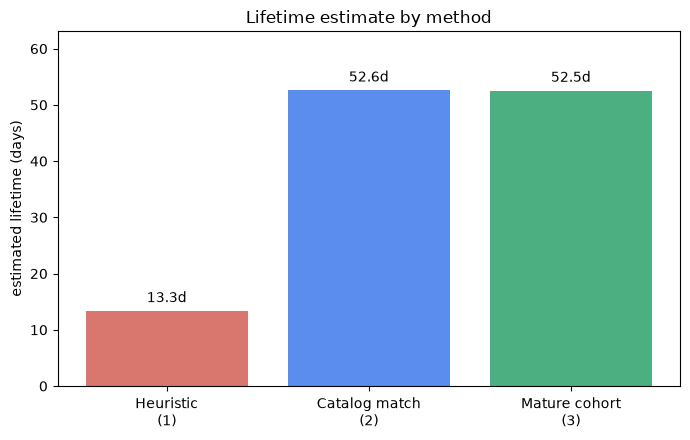

In [11]:
# 세 추정치를 막대그래프로 비교
labels = ['Heuristic\n(1)', 'Catalog match\n(2)', 'Mature cohort\n(3)']
values = compare['lifetime'].tolist()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, values, color=['#d9776f', '#5b8def', '#4caf82'])
ax.set_ylabel('estimated lifetime (days)')
ax.set_title('Lifetime estimate by method')
ax.set_ylim(0, max(values) * 1.2)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f'{v:.1f}d', ha='center', va='bottom')
plt.tight_layout(); plt.show()

같은 신규 코호트의 7일치 데이터를 봤는데, 세 방법은 약 **13 / 53 / 53일**이라는 꽤 다른
답을 내놓습니다. 엄밀히 말하면 *지금 이 시점에 정답을 알 길은 없습니다* — 신규 코호트가
실제로 1년을 살아내야 정답이 나오기 때문입니다. 대신 세 답이 왜 다른지를 읽을 수 있습니다.

- **1)이 가장 작은 이유**: 등비급수 가정이 두꺼운 꼬리를 표현하지 못합니다. 후반 며칠의
  r=0.979를 358일 내내 곱하지만, 실제 꼬리는 시간이 갈수록 r이 1에 더 가까워져 더 두꺼워지는
  경향이 있어 lifetime이 작게 깎입니다.
- **2)·3)가 거의 같은 53일에서 만난 이유**: 출발점이 완전히 다른데도 비슷한 답을 낸 건,
  둘 다 *D7 이후의 두꺼운 꼬리*를 어떤 식으로든 인정하기 때문입니다 — 2)는 sBG 곡선이,
  3)는 장기 코호트의 실측 lifetime이 그 꼬리를 이미 품고 있습니다.

여기서 실무적 교훈 하나 — **두 가지 이상의 방법이 비슷한 답을 내놓을 때 그 답을 더 신뢰할 수
있습니다**(일종의 삼각측량). 이번엔 2)·3)가 53일에서 만났고 1)만 멀리 떨어져,
"13일이라는 답은 의심해 봐야 한다"는 신호로 읽힙니다.

## 실습을 마무리하며

만약 ARPDAU가 0.015달러라면 휴리스틱의 13일은 유저당 LTV 약 0.2달러, 카탈로그와 장기
코호트의 53일은 약 0.79달러가 됩니다. 어느 숫자를 믿느냐에 따라 마케팅 CAC 상한선이 네 배
가까이 달라지는 셈이죠.

여기서 한 가지 명심해야 할 점이 있습니다. 그 어떤 고급 추론 알고리즘이나 고도화된 통계
기법이라도, 데이터 본질에 내재된 불확실성을 100% 제거할 수는 없다는 사실입니다. 모형은
어디까지나 현실을 모사한 도구일 뿐입니다. 따라서 실무에서 LTV나 lifetime 추정치를 다룰 때는
다음 두 가지 원칙을 반드시 기억해야 합니다.

1. **단일 추정치를 절대적인 진리(Absolute Ground Truth)로 과신하지 말 것** — 하나의 수치에
   과도한 확신을 가지면 잘못된 의사결정을 할 수 있습니다.
2. **최소 두 가지 이상의 추정 방식을 교차 비교할 것** — 서로 다른 가정을 가진 모델들을 함께
   검증해야 추정치의 불확실성을 줄이고 신뢰도를 확보할 수 있습니다.